# Testing GRU on METAHATE dataset

In [8]:
import pandas as pd
import re
import string
import numpy as np

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2026-03-17 17:46:17.281294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773769577.306116      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773769577.313586      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773769577.333368      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773769577.333405      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773769577.333408      55 computation_placer.cc:177] computation placer alr

In [9]:
DATA_PATH = "//kaggle/input/datasets/mrsikandarali/metahate-dataset/your_dataset_updated.tsv"

df = pd.read_csv(DATA_PATH, sep="\t")

print(df.head())
print("Dataset shape:", df.shape)

   label                                               text
0      0  !!! RT @mayasolovely: As a woman you shouldn't...
1      0  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2      0  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3      0  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4      0  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
Dataset shape: (1101165, 2)


In [10]:
texts = df['text'].astype(str)
labels = df['label']

# show updated dataset
print(df.head())
print("Dataset shape:", df.shape)

   label                                               text
0      0  !!! RT @mayasolovely: As a woman you shouldn't...
1      0  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2      0  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3      0  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4      0  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
Dataset shape: (1101165, 2)


### Text Cleaning Function

In [11]:
def clean_text(text):
    text = text.lower()                        # lowercase
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"#\w+", "", text)           # remove hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)    # remove special chars
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

texts = texts.apply(clean_text)

In [12]:
df["clean_text"] = df["text"].apply(clean_text)

print(df[["label", "text", "label", "clean_text"]].head(10))

   label                                               text  label  \
0      0  !!! RT @mayasolovely: As a woman you shouldn't...      0   
1      0  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...      0   
2      0  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...      0   
3      0  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...      0   
4      0  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...      0   
5      0  !!!!!!!!!!!!!!!!!!"@T_Madison_x: The shit just...      0   
6      0  !!!!!!"@__BrighterDays: I can not just sit up ...      0   
7      0  !!!!&#8220;@selfiequeenbri: cause I'm tired of...      0   
8      0  " &amp; you might not get ya bitch back &amp; ...      0   
9      0  " @rhythmixx_ :hobbies include: fighting Maria...      0   

                                          clean_text  
0  rt as a woman you shouldnt complain about clea...  
1  rt boy dats coldtyga dwn bad for cuffin dat ho...  
2  rt dawg rt you ever fuck a bitch and she start...  
3        

### Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.1, random_state=42, stratify=labels
)

### Tokenization (Convert words → numbers)

In [14]:
MAX_VOCAB = 50000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

### Padding (Make same length sequences)

In [15]:
MAX_LEN = 100  # you can tune (e.g., 128)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

### Convert to PyTorch Tensors

In [16]:
import torch

X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

### Create Dataset + DataLoader

In [17]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# imports for GRU

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

### GPU Optimization

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### GRU Model (Optimized)

Includes: Embedding layer, Bidirectional GRU, Dropout (avoid overfitting) and Fully connected layer

In [20]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(GRUModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        
        self.dropout = nn.Dropout(0.3)
        
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = self.embedding(x)                      # (batch, seq_len, embed_dim)
        
        _, hidden = self.gru(x)                    # hidden shape: (2, batch, hidden_dim)
        
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # bidirectional
        
        x = self.dropout(hidden)
        
        return self.fc(x)

### Hyperparameters (Tuned for Large Data)

In [21]:
VOCAB_SIZE = 50000
EMBED_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 2   # change if multiclass

BATCH_SIZE = 256   # larger batch for GPU
EPOCHS = 5
LR = 1e-3

### Model Initialization

In [22]:
model = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)
model = model.to(device)

# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

#DataLoader (IMPORTANT for speed)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=4,
    pin_memory=True
)

### Training Loop (Optimized)

In [23]:
 from tqdm import tqdm

for epoch in range(EPOCHS):
    
    model.train()
    total_loss = 0
    
    for inputs, labels in tqdm(train_loader):
        
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        # Gradient clipping (important for GRU stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 3872/3872 [01:15<00:00, 51.58it/s]


Epoch 1, Loss: 0.3241


100%|██████████| 3872/3872 [01:13<00:00, 52.81it/s]


Epoch 2, Loss: 0.2776


100%|██████████| 3872/3872 [01:12<00:00, 53.69it/s]


Epoch 3, Loss: 0.2552


100%|██████████| 3872/3872 [01:12<00:00, 53.27it/s]


Epoch 4, Loss: 0.2336


100%|██████████| 3872/3872 [01:12<00:00, 53.23it/s]

Epoch 5, Loss: 0.2126


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8808
Precision: 0.8776
Recall   : 0.8808
F1 Score : 0.8788


In [25]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     86788
           1       0.74      0.68      0.71     23329

    accuracy                           0.88    110117
   macro avg       0.83      0.81      0.82    110117
weighted avg       0.88      0.88      0.88    110117



In [26]:
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[81201  5587]
 [ 7543 15786]]


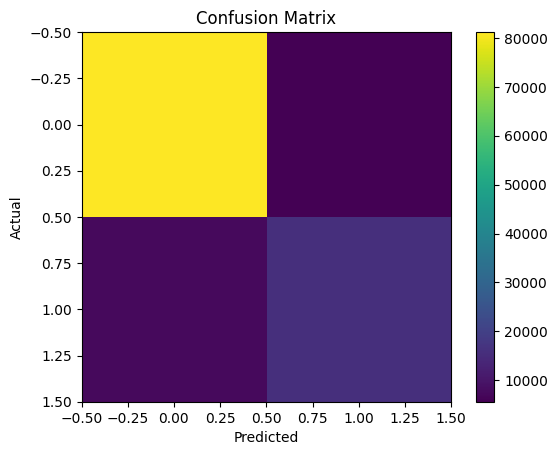

In [27]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()